In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset=pd.read_csv("NYC.csv")
dataset=dataset.drop("id" ,axis=1)

In [3]:
dataset.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1458644 non-null  int64  
 1   pickup_datetime     1458644 non-null  object 
 2   dropoff_datetime    1458644 non-null  object 
 3   passenger_count     1458644 non-null  int64  
 4   pickup_longitude    1458644 non-null  float64
 5   pickup_latitude     1458644 non-null  float64
 6   dropoff_longitude   1458644 non-null  float64
 7   dropoff_latitude    1458644 non-null  float64
 8   store_and_fwd_flag  1458644 non-null  object 
 9   trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 111.3+ MB


In [5]:
dataset.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [6]:
dataset.shape

(1458644, 10)

In [7]:
print(dataset.isnull().sum()) 

vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64


In [8]:
print(dataset.columns[dataset.columns == ""])

Index([], dtype='object')


In [9]:
(dataset == "").sum()

vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [10]:
(dataset == " ").sum()

vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

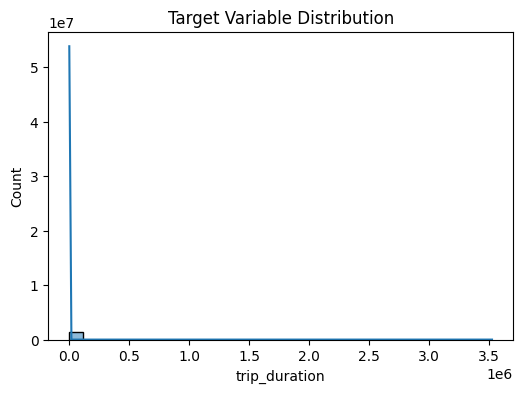

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(dataset['trip_duration'], kde=True,bins=30)
plt.title('Target Variable Distribution')
plt.show()

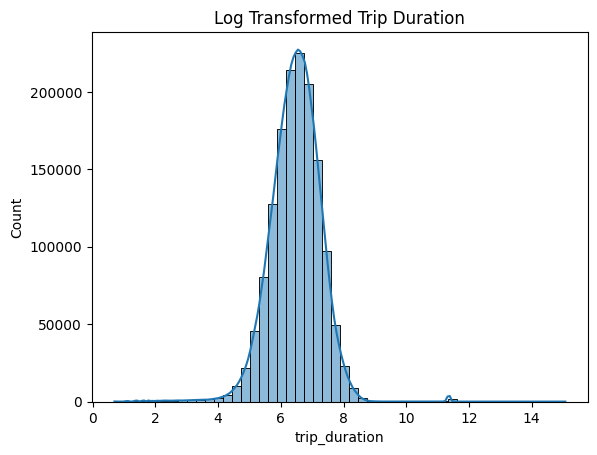

In [12]:
sns.histplot(np.log1p(dataset['trip_duration']), bins=50, kde=True)
plt.title("Log Transformed Trip Duration")
plt.show()

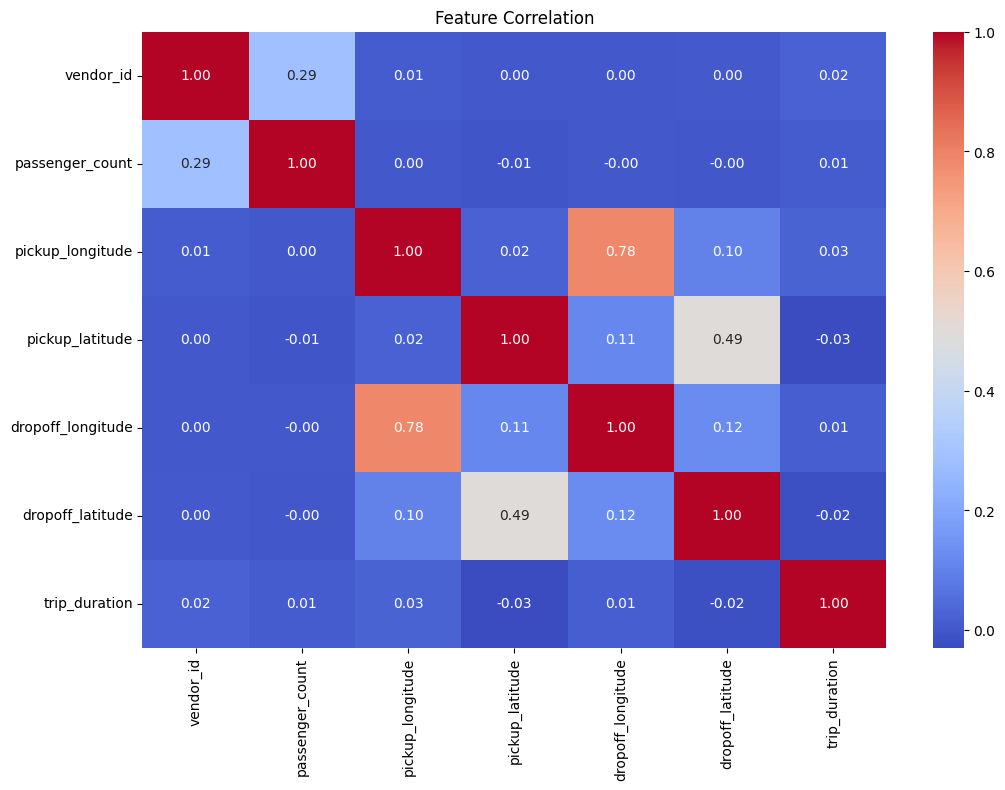

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(dataset.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [14]:
cat_cols=dataset.select_dtypes(exclude=np.number).columns
cat_cols=list(cat_cols)
print(cat_cols)

['pickup_datetime', 'dropoff_datetime', 'store_and_fwd_flag']


In [15]:
dataset = dataset[dataset["trip_duration"] < dataset["trip_duration"].quantile(0.99)]
dataset = dataset[dataset["trip_duration"] > 10]

In [16]:
X = dataset.drop('trip_duration', axis=1)
y = dataset['trip_duration']

In [17]:
dataset.shape

(1441885, 10)

In [18]:
X.shape

(1441885, 9)

In [19]:
from sklearn.model_selection import train_test_split
X_train ,X_test ,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=0  )

In [20]:
X_train.shape

(1153508, 9)

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin

class PreprocessTransformer(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, d):
        d = d.copy()
        
        # datetime
        d['pickup_datetime'] = pd.to_datetime(d['pickup_datetime'])
        d['dropoff_datetime'] = pd.to_datetime(d['dropoff_datetime'])
        
        d['pickup_hour'] = d['pickup_datetime'].dt.hour

        d['day_of_week'] = d['pickup_datetime'].dt.dayofweek
        d['is_weekend'] = d['day_of_week'].apply(lambda x: 1 if x > 5 else 0)
        d['is_rush_hour'] = d['pickup_hour'].isin([7,8,9,10,16,17,18,19,20]).astype(int)

        # haversine
        def haversine(lat1, lon1, lat2, lon2):
            R = 6371
            lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
            dlat = lat2 - lat1
            dlon = lon2 - lon1
            a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
            c = 2 * np.arcsin(np.sqrt(a))
            return R * c

        def manhattan(lat1, lon1, lat2, lon2):
            return (
                haversine(lat1, lon1, lat2, lon1) +
                haversine(lat2, lon1, lat2, lon2)
            )

        def bearing(lat1, lon1, lat2, lon2):
            lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
            dlon = lon2 - lon1
            x = np.sin(dlon) * np.cos(lat2)
            y = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
            angle = np.degrees(np.arctan2(x, y))
            return (angle + 360) % 360

        d['haversine_km'] = haversine(
            d['pickup_latitude'], d['pickup_longitude'],
            d['dropoff_latitude'], d['dropoff_longitude']
        )
        
        d['manhattan_km'] = manhattan(
            d['pickup_latitude'], d['pickup_longitude'],
            d['dropoff_latitude'], d['dropoff_longitude']
        )
        

        # flag encoding
        d['store_and_fwd_flag'] = (
            d['store_and_fwd_flag']
            .astype(str)
            .str.strip()
            .str.lower()
            .map({'y':1, 'n':0})
            .fillna(0)
        )

        d.drop([
            'pickup_latitude',
            'pickup_longitude',
            'dropoff_latitude',
            'dropoff_longitude',
            'pickup_datetime',
            'dropoff_datetime'
        ], axis=1, inplace=True)

        return d

In [22]:
from sklearn.base import BaseEstimator, TransformerMixin
class OutlierHandling(BaseEstimator, TransformerMixin):
    
    def __init__(self, columns, lower_quantile=0.05, upper_quantile=0.95):
        self.columns = columns
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile
        self.bounds = {}
    
    def fit(self, X, y=None):
        X = X.copy()
        
        for col in self.columns:
            lower = X[col].quantile(self.lower_quantile)
            upper = X[col].quantile(self.upper_quantile)
            
            self.bounds[col] = (lower, upper)
        
        return self
    
    def transform(self, X):
        X = X.copy()
        
        for col in self.columns:
            lower, upper = self.bounds[col]
            X[col] = X[col].clip(lower, upper)
        
        return X

In [38]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

pipe = Pipeline([
    ("preprocess", PreprocessTransformer()),
    ("outlier", OutlierHandling(columns=['haversine_km', 'manhattan_km'])),
    ("model", XGBRegressor())
])

final_model = TransformedTargetRegressor(
    regressor=pipe,
    func=np.log1p,
    inverse_func=np.expm1
)


In [28]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "regressor__model__n_estimators": [200, 300, 400, 600],
    "regressor__model__max_depth": [4, 6, 8, 10],
    "regressor__model__learning_rate": [0.01, 0.05, 0.1],
    "regressor__model__subsample": [0.6, 0.8, 1.0],
    "regressor__model__colsample_bytree": [0.6, 0.8, 1.0],
    "regressor__model__min_child_weight": [1, 3, 5],
}

random = RandomizedSearchCV(
    final_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',#iss basis pai best estimator choose hota hai
    n_jobs=-1,
    random_state=42
)

random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","TransformedTa...None, ...))]))"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__model__colsample_bytree': [0.6, 0.8, ...], 'regressor__model__learning_rate': [0.01, 0.05, ...], 'regressor__model__max_depth': [4, 6, ...], 'regressor__model__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same acr

In [29]:
print("Best Parameters are:",random.best_params_)
best_model = random.best_estimator_
y_pred =best_model.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate(
    (y_pred.reshape(-1,1), y_test.to_numpy().reshape(-1,1)),axis=1))

Best Parameters are: {'regressor__model__subsample': 1.0, 'regressor__model__n_estimators': 200, 'regressor__model__min_child_weight': 3, 'regressor__model__max_depth': 8, 'regressor__model__learning_rate': 0.1, 'regressor__model__colsample_bytree': 1.0}
[[ 583.36  634.  ]
 [ 210.15  207.  ]
 [1634.69 1944.  ]
 ...
 [ 979.81  880.  ]
 [ 802.21 1226.  ]
 [ 734.54  665.  ]]


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R2 score : {r2:,.2f}")

print(f"R2 Score(%): {r2 * 100:.2f} %")

MAE  : 214.31
MSE  : 100,183.01
RMSE : 316.52
R2 score : 0.70
R2 Score(%): 69.77 %


In [ ]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     "regressor__model__n_estimators": [200, 300, 400],
#     "regressor__model__max_depth": [4, 6, 8],
#     "regressor__model__learning_rate": [0.01, 0.05],
# }

# grid = GridSearchCV(
#     final_model,
#     param_grid=param_grid,
#     cv=3,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1
# )

# grid.fit(X_train, y_train)

In [44]:
def objective(trial):

    params = {
        "regressor__model__n_estimators": trial.suggest_int("regressor__model__n_estimators", 200, 800),
        "regressor__model__max_depth": trial.suggest_int("regressor__model__max_depth", 3, 12),
        "regressor__model__learning_rate": trial.suggest_float("regressor__model__learning_rate", 0.01, 0.2, log=True),
        "regressor__model__subsample": trial.suggest_float("regressor__model__subsample", 0.6, 1.0),
        "regressor__model__colsample_bytree": trial.suggest_float("regressor__model__colsample_bytree", 0.6, 1.0),
        "regressor__model__min_child_weight": trial.suggest_int("regressor__model__min_child_weight", 1, 10),
    }

    model = final_model.set_params(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,   # better than 2
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    ).mean()

    return score

In [45]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

[I 2026-04-26 00:37:45,922] A new study created in memory with name: no-name-7dcb7747-3293-46d8-8396-e6ce085c0a1c
[I 2026-04-26 00:39:05,762] Trial 0 finished with value: -317.9808756510417 and parameters: {'regressor__model__n_estimators': 423, 'regressor__model__max_depth': 10, 'regressor__model__learning_rate': 0.19999011554869256, 'regressor__model__subsample': 0.8235541922979446, 'regressor__model__colsample_bytree': 0.6047936448191921, 'regressor__model__min_child_weight': 7}. Best is trial 0 with value: -317.9808756510417.
[I 2026-04-26 00:39:55,209] Trial 1 finished with value: -329.314453125 and parameters: {'regressor__model__n_estimators': 522, 'regressor__model__max_depth': 3, 'regressor__model__learning_rate': 0.013438453555892916, 'regressor__model__subsample': 0.7071799444878321, 'regressor__model__colsample_bytree': 0.930966335756677, 'regressor__model__min_child_weight': 9}. Best is trial 0 with value: -317.9808756510417.
[I 2026-04-26 00:41:18,633] Trial 2 finished wi

In [46]:
print(study.best_params)

{'regressor__model__n_estimators': 660, 'regressor__model__max_depth': 9, 'regressor__model__learning_rate': 0.04550649111539824, 'regressor__model__subsample': 0.8315129917127636, 'regressor__model__colsample_bytree': 0.8696699722501873, 'regressor__model__min_child_weight': 7}


In [48]:
best_params = study.best_params

final_model.set_params(
    regressor__model__n_estimators=best_params["regressor__model__n_estimators"],
    regressor__model__max_depth=best_params["regressor__model__max_depth"],
    regressor__model__learning_rate=best_params["regressor__model__learning_rate"],
    regressor__model__subsample=best_params["regressor__model__subsample"],
    regressor__model__colsample_bytree=best_params["regressor__model__colsample_bytree"],
    regressor__model__min_child_weight=best_params["regressor__model__min_child_weight"]
)

best_model = final_model
best_model.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.","Pipeline(step...=None, ...))])"
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,columns,"['haversine_km', 'manhattan_km']"
,lower_quantile,0.05
,upper_quantile,0.95
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None


In [49]:
y_pred = best_model.predict(X_test)

np.set_printoptions(precision=2)

print(
    np.concatenate(
        (y_pred.reshape(-1,1), y_test.to_numpy().reshape(-1,1)),
        axis=1
    )
)

[[ 581.69  634.  ]
 [ 223.42  207.  ]
 [1633.76 1944.  ]
 ...
 [ 988.92  880.  ]
 [ 813.73 1226.  ]
 [ 725.63  665.  ]]


In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R2 score : {r2:,.2f}")

print(f"R2 Score(%): {r2 * 100:.2f} %")

MAE  : 214.18
MSE  : 100,064.35
RMSE : 316.33
R2 score : 0.70
R2 Score(%): 69.80 %


In [51]:
new_data = pd.DataFrame([{
    'vendor_id':1,            
    'pickup_datetime':'2016-06-12 00:43:35',     
    'dropoff_datetime':'2016-06-12 00:54:38',
    'passenger_count':1,   
    'pickup_longitude':-73.980415344238281 ,
    'pickup_latitude':40.738563537597656 ,  
    'dropoff_longitude':-73.999481201171875 ,   
    'dropoff_latitude':40.731151580810547 ,   
    'store_and_fwd_flag':'N'
}])

pred_duration= best_model.predict(new_data)
# pred_duration=np.expm1(pred_duration_log)
value = pred_duration.item()
print("Predicted trip duration (sec):", round(value, 2))
print("Predicted trip duration (min):", round(value / 60, 2))
# fare = fare_estimate(new_data, pred_duration.item())
# print("Estimated Fare ($):", round(fare, 2))
# print("Estimated distance (km):", round(new_data['haversine_km'].iloc[0], 2))
# distance = new_data['haversine_km'].iloc[0]
# time_hr = pred_duration[0] / 3600

# speed = distance / time_hr

# print("Estimated speed (km/h):", round(speed.item(), 2))

Predicted trip duration (sec): 477.2
Predicted trip duration (min): 7.95
